<a href="https://colab.research.google.com/github/leonardeugenia-hash/TGF2026/blob/main/datos1_spotify_pib_internet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Carga de datos

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller

# nos aseguramos de poder ver todas las columnas
pd.set_option("display.max_columns", None)

# leemos los archivos que vamos a usar en este script
df_spotify = pd.read_csv("spotify_tfg_2010_2024.csv")
df_pib = pd.read_excel("pib_per_capita_2010_2024.xls", header=3)
df_internet = pd.read_excel("internt_access_2010_2024.xls", header=3)


df_internet.columns = df_internet.columns.astype(str).str.strip()
df_pib.columns = df_pib.columns.astype(str).str.strip()

# estructura de cada uno de los 3 archivos
print(f"Spotify:  {df_spotify.shape[0]} canciones, {df_spotify.shape[1]} columnas")
print(f"PIB:      {df_pib.shape}")
print(f"Internet: {df_internet.shape}")

df_spotify.head()


def styled_table(df, caption=''):
    return (
        df.style
        .set_caption(caption)
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '13px'), ('font-weight', 'bold'), ('padding-bottom', '8px')]},
            {'selector': 'thead th',
             'props': [('background-color', '#1a3a5c'), ('color', 'white'),
                       ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'tbody tr:nth-child(even)',
             'props': [('background-color', '#f0f4f8')]},
            {'selector': 'tbody tr:hover',
             'props': [('background-color', '#d6e4f0')]},
            {'selector': 'td, th',
             'props': [('padding', '6px 12px'), ('text-align', 'center')]},
        ])
        .format(precision=2)
    )


Spotify:  1185 canciones, 18 columnas
PIB:      (266, 69)
Internet: (266, 69)


Diagnostico del dataset de Spotify

In [ ]:
print("=" * 55)
print("ESTRUCTURA GENERAL DE LOS DATOS DE SPOTIFY")
print("=" * 55)

if 'duration_min' not in df_spotify.columns:
    df_spotify['duration_min'] = df_spotify['duration_ms'] / 60000

# Tabla de estructura de columnas
df_estructura = pd.DataFrame({
    '#': range(len(df_spotify.columns)),
    'Columna': df_spotify.columns,
    'Nulos': [df_spotify[col].isnull().sum() for col in df_spotify.columns],
    'Tipo': [str(df_spotify[col].dtype) for col in df_spotify.columns],
})
display(styled_table(df_estructura, f'Estructura del dataset Spotify ({df_spotify.shape[1]} columnas)').format({'#': '{:.0f}', 'Nulos': '{:.0f}'}))

# Tabla duplicados
dup_total   = df_spotify.duplicated().sum()
dup_cancion = df_spotify.duplicated(subset=["track_id", "source_year"]).sum()
df_dup = pd.DataFrame({
    'Métrica': ['Filas completamente duplicadas', 'Canciones duplicadas dentro del mismo año'],
    'Valor': [dup_total, dup_cancion]
})
display(styled_table(df_dup, 'Duplicados').format({'Valor': '{:.0f}'}))

# Distribución por año
vc_year = df_spotify["source_year"].value_counts().sort_index().reset_index()
vc_year.columns = ['Año', 'N canciones']
display(styled_table(vc_year, 'Distribución por año').format({'Año': '{:.0f}', 'N canciones': '{:.0f}'}))

# Estadísticos numéricos
cols_numericas = [col for col in df_spotify.select_dtypes(include='number').columns if col != 'duration_ms']
desc_num = df_spotify[cols_numericas].describe().T.round(2)
desc_num['count'] = desc_num['count'].astype(int)
cols_stat = ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
year_rows  = [r for r in ['source_year', 'release_year'] if r in desc_num.index]
other_rows = desc_num.index.difference(year_rows).tolist()

display(
    desc_num.style
    .background_gradient(cmap='Blues', subset=['mean', 'std'])
    .background_gradient(cmap='Reds', subset=['max'])
    .background_gradient(cmap='Greens', subset=['min'])
    .format(lambda v: f'{v:.0f}', subset=(year_rows, cols_stat))
    .format(lambda v: f'{int(v):d}', subset=(other_rows, ['count']))
    .format(lambda v: f'{int(v):d}', subset=(year_rows, ['count']))
    .format(lambda v: f'{v:.2f}', subset=(other_rows, cols_stat))
    .set_caption('Estadísticas descriptivas: variables numéricas')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold'), ('padding-bottom', '8px')]},
        {'selector': 'thead th', 'props': [('background-color', '#1a3a5c'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#f0f4f8')]},
        {'selector': 'tbody tr:hover', 'props': [('background-color', '#d6e4f0')]},
        {'selector': 'td, th', 'props': [('padding', '6px 12px'), ('text-align', 'center')]},
    ])
)


ESTRUCTURA GENERAL DE LOS DATOS DE SPOTIFY


,#,Columna,Nulos,Tipo
0,0,playlist_id,0,object
1,1,playlist_name,0,object
2,2,source_year,0,int64
3,3,source_label,0,object
4,4,track_id,0,object
5,5,track_name,0,object
6,6,artist_id,0,object
7,7,artist_name,0,object
8,8,album_id,0,object
9,9,album_name,0,object


,Métrica,Valor
0,Filas completamente duplicadas,0
1,Canciones duplicadas dentro del mismo año,0


,Año,N canciones
0,2010,50
1,2011,50
2,2012,50
3,2013,50
4,2014,50
5,2015,95
6,2016,98
7,2017,96
8,2018,94
9,2019,96


,count,mean,std,min,25%,50%,75%,max
source_year,1185,2018,4,2010,2015,2018,2021,2024
release_year,1185,2018,4,1980,2015,2018,2021,2025
explicit,1185,0.14,0.34,0.00,0.00,0.00,0.00,1.00
popularity,1185,54.80,19.26,0.00,42.00,57.00,70.00,90.00
duration_sec,1185,213.31,40.92,105.84,187.44,209.92,233.07,519.29
artist_popularity,1185,66.52,16.30,2.00,55.00,69.00,80.00,100.00
duration_min,1185,3.56,0.68,1.76,3.12,3.50,3.88,8.65


In [ ]:
cols_categoricas = df_spotify.select_dtypes(exclude='number').columns.tolist()
desc_cat = df_spotify[cols_categoricas].describe(include='all').T[['count', 'unique', 'top', 'freq']].copy()
desc_cat['count'] = desc_cat['count'].astype(int)
desc_cat['freq']  = desc_cat['freq'].astype(int)

display(
    desc_cat.style
    .background_gradient(cmap='Purples', subset=['unique'])
    .background_gradient(cmap='Oranges', subset=['freq'])
    .format({'count': '{:d}', 'freq': '{:,}'})
    .set_caption('Estadísticas descriptivas: variables categóricas')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold'), ('padding-bottom', '8px')]},
        {'selector': 'thead th', 'props': [('background-color', '#1a3a5c'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#f0f4f8')]},
        {'selector': 'tbody tr:hover', 'props': [('background-color', '#d6e4f0')]},
        {'selector': 'td, th', 'props': [('padding', '6px 12px'), ('text-align', 'center')]},
    ])
)


,count,unique,top,freq
playlist_id,1185,15,1d4QC8coOQPkxKKz1moFPZ,98
playlist_name,1185,15,2016 españa - TFG EILH,98
source_label,1185,15,Top Hits 2016,98
track_id,1185,1132,1m69ELEgE6k5ZWsap40ozt,3
track_name,1185,1105,París,3
artist_id,1185,464,4q3ewBCX7sLwd24euuV69X,22
artist_name,1185,464,Bad Bunny,22
album_id,1185,1000,4kS7bSuU0Jm9LYMosFU2x5,9
album_name,1185,987,MAÑANA SERÁ BONITO,9
release_date,1185,723,2013-01-01,14


Limpieza del dataset de Spotify

In [ ]:
# copiamos para no podificar los datos originales
df_spotify_clean = df_spotify.copy()

# eliminamos columnas innecesarias
cols_drop = [
    "playlist_id", "playlist_name", "artist_id",
    "album_id", "duration_ms", "source_label"]
df_spotify_clean = df_spotify_clean.drop(columns=cols_drop)

# cambianos nombre a source_year
df_spotify_clean = df_spotify_clean.rename(columns={"source_year": "year"})

# cambiamos los tipos de variables
df_spotify_clean["year"]         = df_spotify_clean["year"].astype(int)
df_spotify_clean["release_year"] = pd.to_numeric(df_spotify_clean["release_year"], errors="coerce").astype("Int64")
df_spotify_clean["release_date"] = pd.to_datetime(df_spotify_clean["release_date"], errors="coerce")

# creamos variable: mes de lanzamiento
df_spotify_clean["release_month"] = df_spotify_clean["release_date"].dt.month

# creamos variable: antigüedad de la canción en el momento de entrar en la lista
df_spotify_clean['years_since_release'] = df_spotify_clean['year'] - df_spotify_clean['release_year']


# creamos variable: género principal (el primero de la lista)
# Convert artist_genres to string to handle potential non-string types, then split and take the first element.
# If artist_genres is NaN, str(NaN) becomes "nan", so we convert "nan" strings back to actual pd.NA.
df_spotify_clean["genre_group"] = df_spotify_clean["artist_genres"].astype(str).str.split(", ").str[0]
df_spotify_clean.loc[df_spotify_clean["genre_group"] == "nan", "genre_group"] = pd.NA

print("Columnas finales:", df_spotify_clean.columns.tolist())
print("\nShape:", df_spotify_clean.shape)

df_estructura = pd.DataFrame({
    '#': range(len(df_spotify_clean.columns)),
    'Columna': df_spotify_clean.columns,
    'Nulos': [df_spotify_clean[col].isnull().sum() for col in df_spotify_clean.columns],
    'Tipo': [str(df_spotify_clean[col].dtype) for col in df_spotify_clean.columns],
})
display(styled_table(df_estructura, f'Estructura del dataset Spotify ({df_spotify_clean.shape[1]} columnas)').format({'#': '{:.0f}', 'Nulos': '{:.0f}'}))

Columnas finales: ['year', 'track_id', 'track_name', 'artist_name', 'album_name', 'release_date', 'release_year', 'explicit', 'popularity', 'duration_sec', 'artist_popularity', 'artist_genres', 'duration_min', 'release_month', 'years_since_release', 'genre_group']

Shape: (1185, 16)


,#,Columna,Nulos,Tipo
0,0,year,0,int64
1,1,track_id,0,object
2,2,track_name,0,object
3,3,artist_name,0,object
4,4,album_name,0,object
5,5,release_date,10,datetime64[ns]
6,6,release_year,0,Int64
7,7,explicit,0,int64
8,8,popularity,0,int64
9,9,duration_sec,0,float64


Limpieza de nulos

In [ ]:
nulos_fecha = df_spotify_clean[df_spotify_clean["release_date"].isna()][["year", "track_name", "artist_name"]].copy()
nulos_fecha.columns = ["Año", "Canción", "Artista"]
display(styled_table(
    nulos_fecha,
    f'Canciones sin fecha de lanzamiento — {len(nulos_fecha)} casos ({len(nulos_fecha)/len(df_spotify_clean)*100:.1f}%)'
).format({'Año': '{:.0f}'}))
print("→ Decisión: se conservan como nulos.")

nulos_genres = df_spotify_clean[df_spotify_clean["artist_genres"].isna()]
tiene_group  = nulos_genres["genre_group"].notna().sum()
sin_group    = nulos_genres["genre_group"].isna().sum()

df_nulos_gen = pd.DataFrame({
    'Métrica': [
        'Nulos en artist_genres',
        '→ Con genre_group ya asignado (no es problema)',
        '→ Sin genre_group tampoco (necesitan tratamiento)',
    ],
    'Valor': [len(nulos_genres), tiene_group, sin_group]
})
display(styled_table(df_nulos_gen, 'Diagnóstico de nulos en géneros').format({'Valor': '{:.0f}'}))

mask_sin_grupo = df_spotify_clean["artist_genres"].isna() & df_spotify_clean["genre_group"].isna()
df_spotify_clean.loc[mask_sin_grupo, "genre_group"] = "unknown"
print(f"\nCanciones marcadas como 'unknown': {mask_sin_grupo.sum()}")
print("→ artist_genres se conserva como NaN (texto libre, no entra en modelos).")
print("→ genre_group = 'unknown' para los sin información.")

vc_gen = df_spotify_clean["genre_group"].value_counts().reset_index()
vc_gen.columns = ['Genre group', 'N canciones']
display(styled_table(vc_gen, 'Distribución final de genre_group').format({'N canciones': '{:.0f}'}))


,Año,Canción,Artista
2,2010,Cuando Me Enamoro,Enrique Iglesias
27,2010,Chiquitita - Spanish Version,ABBA
49,2010,I Like It,Enrique Iglesias
62,2011,La Quiero a Morir (feat. Alejandro Sanz),Jarabe De Palo
80,2011,Feel The Magic,Pastora
87,2011,El Viejo Verano,El Barrio
101,2012,Tanto,Pablo Alborán
135,2012,Dónde está el amor (feat. Jesse & Joy),Pablo Alborán
590,2018,BEBE (feat. Anuel AA),6ix9ine
1177,2024,Rosas,La Oreja de Van Gogh


→ Decisión: se conservan como nulos.


,Métrica,Valor
0,Nulos en artist_genres,462
1,→ Con genre_group ya asignado (no es problema),0
2,→ Sin genre_group tampoco (necesitan tratamiento),462



Canciones marcadas como 'unknown': 462
→ artist_genres se conserva como NaN (texto libre, no entra en modelos).
→ genre_group = 'unknown' para los sin información.


,Genre group,N canciones
0,unknown,462
1,reggaeton,203
2,flamenco,97
3,latin pop,80
4,indie,29
5,flamenco pop,27
6,argentine trap,26
7,colombian pop,25
8,latin,22
9,singer-songwriter,21


Comprobamos que las modificaciones se hicieron correctamente

In [ ]:
df_estructura = pd.DataFrame({
    '#': range(len(df_spotify_clean.columns)),
    'Columna': df_spotify_clean.columns,
    'Nulos': [df_spotify_clean[col].isnull().sum() for col in df_spotify_clean.columns],
    'Tipo': [str(df_spotify_clean[col].dtype) for col in df_spotify_clean.columns],
})
display(styled_table(df_estructura, f'Estructura del dataset Spotify ({df_spotify_clean.shape[1]} columnas)').format({'#': '{:.0f}', 'Nulos': '{:.0f}'}))

,#,Columna,Nulos,Tipo
0,0,year,0,int64
1,1,track_id,0,object
2,2,track_name,0,object
3,3,artist_name,0,object
4,4,album_name,0,object
5,5,release_date,10,datetime64[ns]
6,6,release_year,0,Int64
7,7,explicit,0,int64
8,8,popularity,0,int64
9,9,duration_sec,0,float64


Outliers por canción

OUTLIERS A NIVEL DE CANCIÓN (método IQR)


,Año,Canción,Artista,Duración (seg),Duración (min)
1,2010,Chiquitita - Spanish Version,ABBA,333.1,5.55
2,2011,Si te vas...,Extremoduro,516.7,8.61
3,2011,Sick of Love,Robert Ramirez,326.4,5.44
4,2013,No Dejes De Soñar,Manuel Carrasco,319.6,5.33
5,2013,El camino de las utopías,Extremoduro,450.5,7.51
6,2014,Mi Problema,Ismael Serrano,366.0,6.10
7,2015,Slowly,Natalia Lafourcade,336.8,5.61
8,2015,A Que No Me Dejas,Alejandro Sanz,311.2,5.19
9,2015,Llévame Muy Lejos,Amaral,336.7,5.61
10,2015,Los Abrazos Rotos (with Alex Ubago),Amaia Montero,305.9,5.10


,Variable,Límite inferior,Límite superior,N outliers,% outliers
0,duration_sec,118.98,301.52,31,2.62
1,popularity,0.00,112.00,0,0.00
2,artist_popularity,17.50,117.50,5,0.42



→ Se conservan todos los outliers para no sesgar las tendencias temporales.

Nota: 'years_since_release' excluida del análisis IQR por distribución degenerada.
Se detectaron 65 canciones con antigüedad negativa (release_year > year), tratadas como datos anómalos.


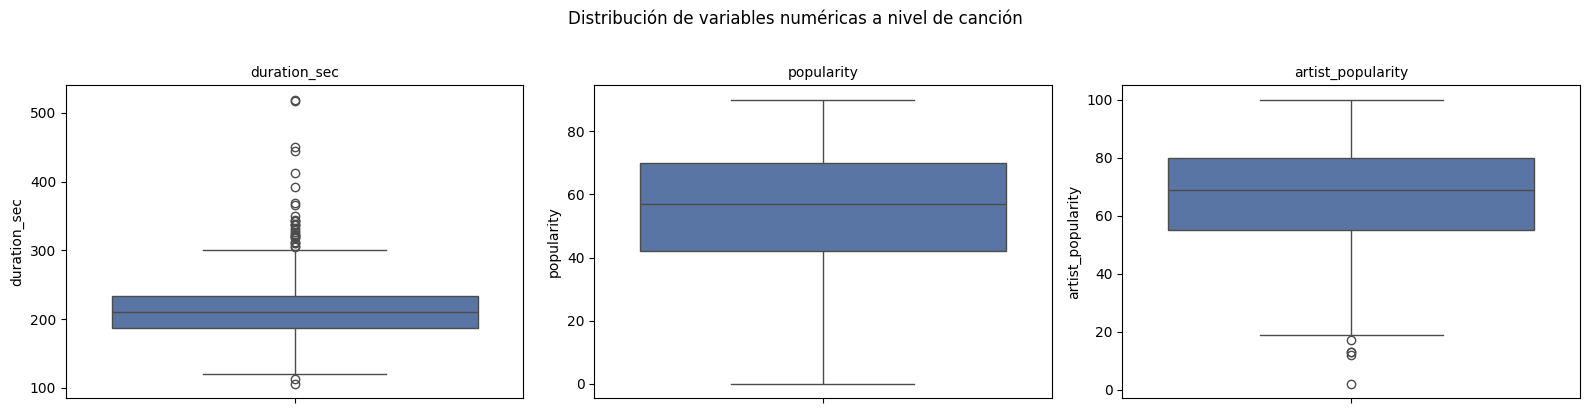

In [ ]:
cols_numericas_cancion = ["duration_sec", "popularity", "artist_popularity"]

print("=" * 55)
print("OUTLIERS A NIVEL DE CANCIÓN (método IQR)")
print("=" * 55)

outlier_resumen = []
for col in cols_numericas_cancion:
    Q1  = df_spotify_clean[col].quantile(0.25)
    Q3  = df_spotify_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_spotify_clean[col] < lower) | (df_spotify_clean[col] > upper)).sum()
    pct   = n_out / len(df_spotify_clean) * 100
    outlier_resumen.append({"Variable": col, "Límite inferior": round(lower, 2),
                             "Límite superior": round(upper, 2),
                             "N outliers": n_out, "% outliers": round(pct, 2)})

    if col == "duration_sec":
        outliers_dur = df_spotify_clean[
            (df_spotify_clean[col] < lower) | (df_spotify_clean[col] > upper)
        ].copy()
        if len(outliers_dur) > 0:
            tabla_dur = outliers_dur[["year", "track_name", "artist_name", "duration_sec", "duration_min"]].sort_values("year").reset_index(drop=True)
            tabla_dur["duration_min"] = tabla_dur["duration_min"].round(2)
            tabla_dur["duration_sec"] = tabla_dur["duration_sec"].round(1)
            tabla_dur.index += 1
            tabla_dur.columns = ["Año", "Canción", "Artista", "Duración (seg)", "Duración (min)"]
            display(
                tabla_dur.style
                .background_gradient(cmap='Oranges', subset=['Duración (min)'])
                .set_caption(f'Canciones con duración atípica — {n_out} casos (método IQR)')
                .set_table_styles([
                    {'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold'), ('padding-bottom', '8px')]},
                    {'selector': 'thead th', 'props': [('background-color', '#1a3a5c'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
                    {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#f0f4f8')]},
                    {'selector': 'tbody tr:hover', 'props': [('background-color', '#d6e4f0')]},
                    {'selector': 'td, th', 'props': [('padding', '6px 12px'), ('text-align', 'center')]},
                ])
                .format({"Duración (seg)": "{:.1f}", "Duración (min)": "{:.2f}", "Año": "{:.0f}"})
            )

df_outliers = pd.DataFrame(outlier_resumen)
display(styled_table(df_outliers, 'Resumen de outliers — método IQR').format({
    'Límite inferior': '{:.2f}', 'Límite superior': '{:.2f}',
    'N outliers': '{:.0f}', '% outliers': '{:.2f}'
}))
print("\n→ Se conservan todos los outliers para no sesgar las tendencias temporales.")

n_negativos = (df_spotify_clean['years_since_release'] < 0).sum()
print(f"\nNota: 'years_since_release' excluida del análisis IQR por distribución degenerada.")
print(f"Se detectaron {n_negativos} canciones con antigüedad negativa (release_year > year), tratadas como datos anómalos.")

fig, axes = plt.subplots(1, len(cols_numericas_cancion), figsize=(16, 4))
for ax, col in zip(axes, cols_numericas_cancion):
    sns.boxplot(y=df_spotify_clean[col], ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.suptitle("Distribución de variables numéricas a nivel de canción", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


Análisis exploratorio a nivel de canción

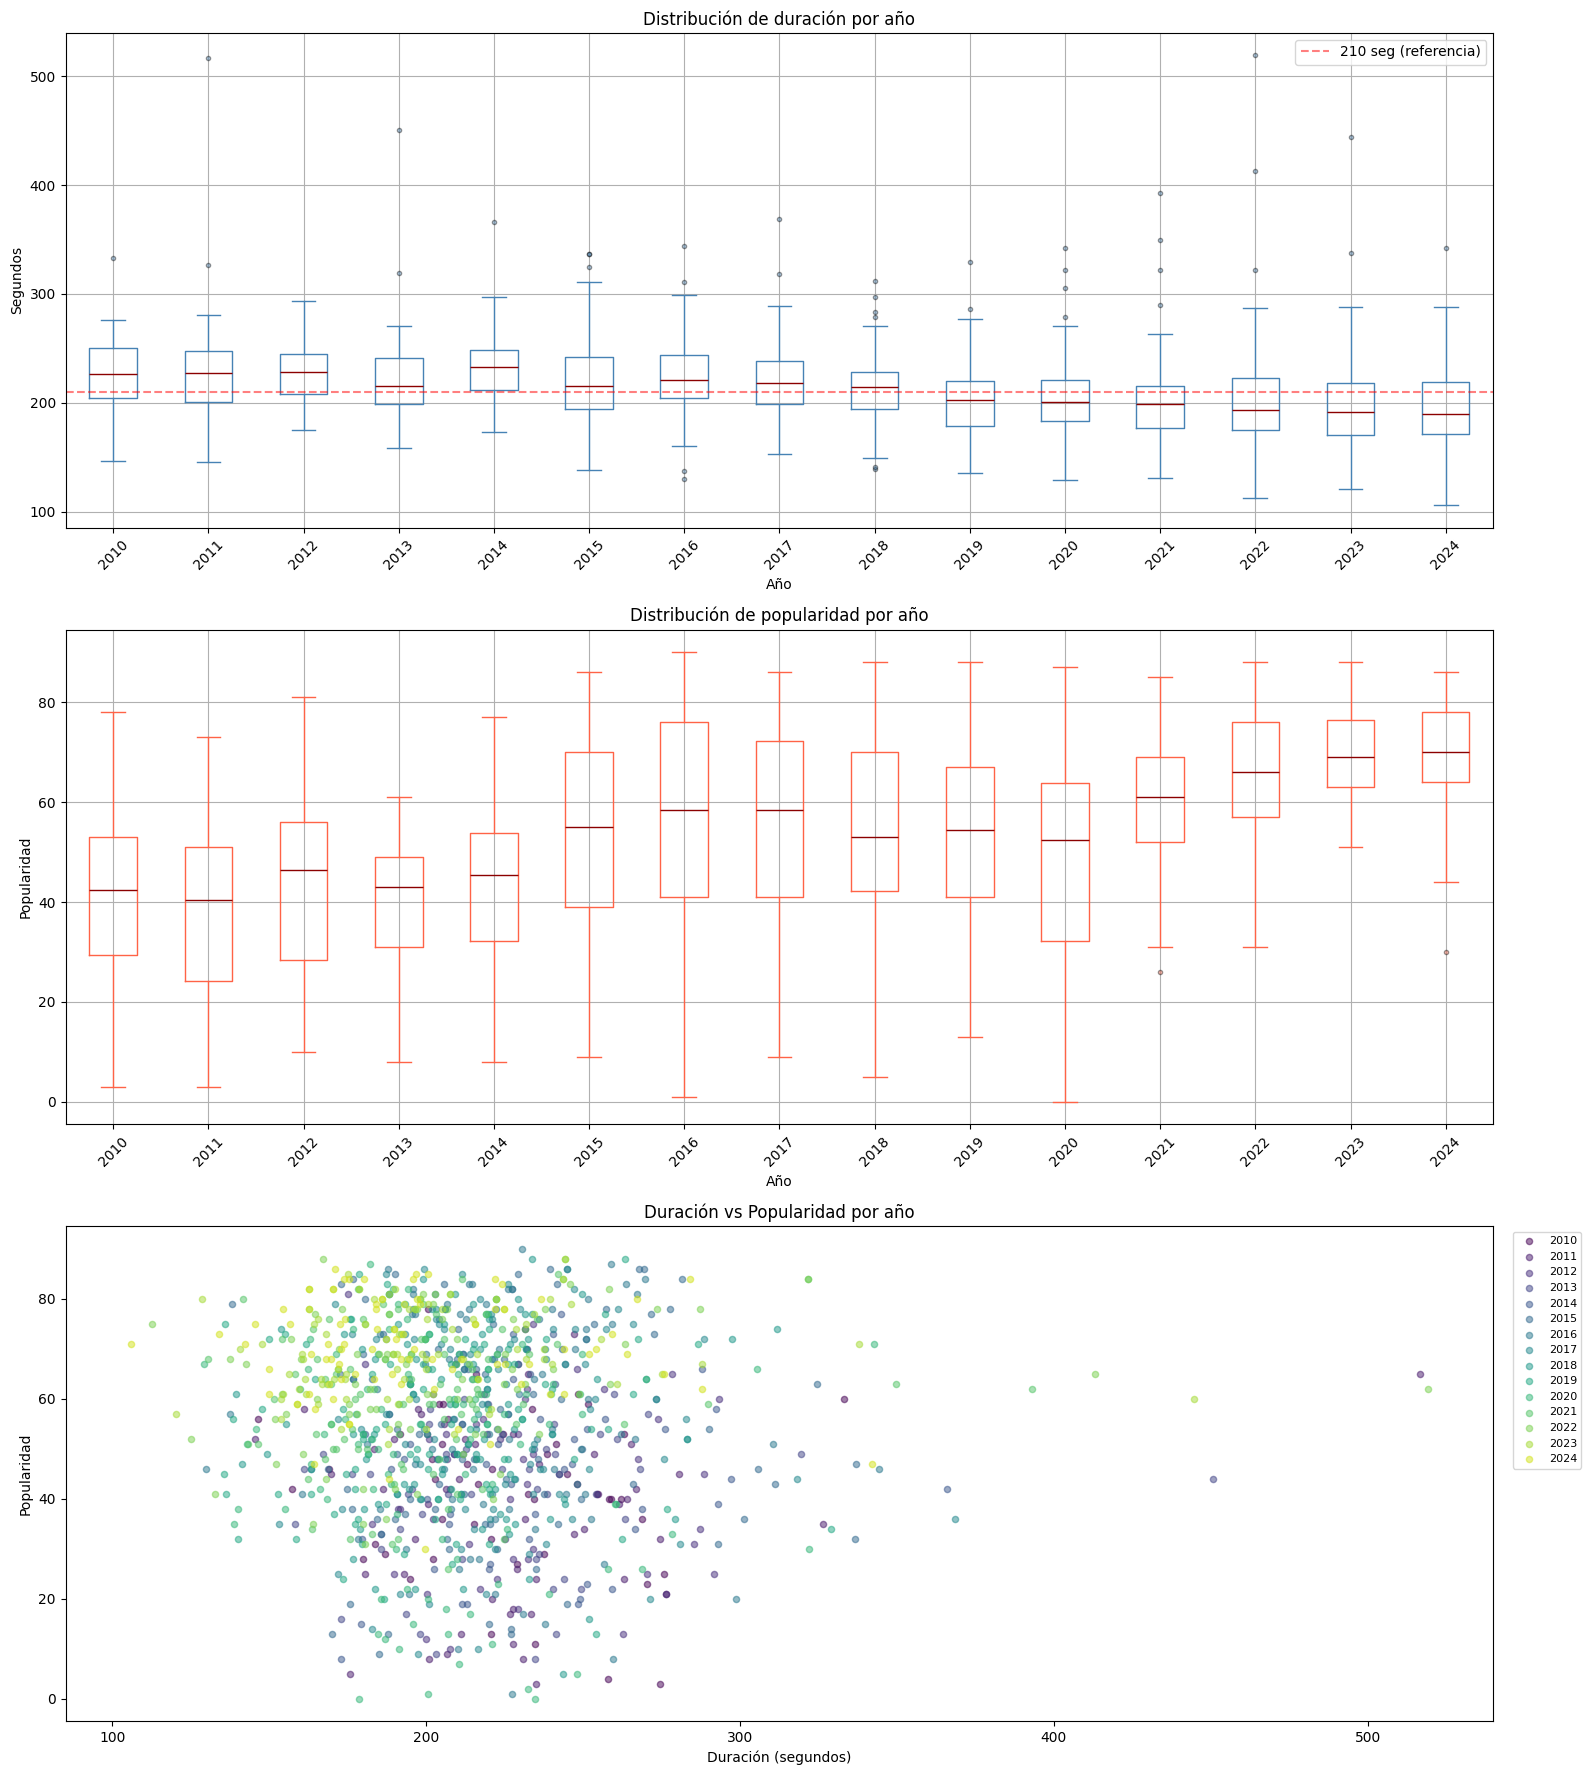

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

# boxplot duración por año ──────────────────────────────
df_spotify_clean.boxplot(
    column='duration_sec',
    by='year',
    ax=axes[0],
    color=dict(boxes='#4682B4', whiskers='#4682B4',
               medians='darkred', caps='#4682B4'),
    flierprops=dict(marker='o', markersize=3,
                    markerfacecolor='#4682B4', alpha=0.4)
)
axes[0].set_title('Distribución de duración por año', fontsize=12)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Segundos')
axes[0].axhline(y=210, color='red', linestyle='--',
                alpha=0.5, label='210 seg (referencia)')
axes[0].legend()
plt.sca(axes[0])
plt.xticks(rotation=45)

# boxplot popularidad por año
df_spotify_clean.boxplot(
    column='popularity',
    by='year',
    ax=axes[1],
    color=dict(boxes='tomato', whiskers='tomato',
               medians='darkred', caps='tomato'),
    flierprops=dict(marker='o', markersize=3,
                    markerfacecolor='tomato', alpha=0.4)
)
axes[1].set_title('Distribución de popularidad por año', fontsize=12)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Popularidad')
plt.sca(axes[1])
plt.xticks(rotation=45)

# dispersión duración vs popularidad por año
años = sorted(df_spotify_clean['year'].unique())
cmap = plt.cm.viridis
colores_años = {año: cmap(i / len(años)) for i, año in enumerate(años)}

for año in años:
    subset = df_spotify_clean[df_spotify_clean['year'] == año]
    axes[2].scatter(
        subset['duration_sec'],
        subset['popularity'],
        color=colores_años[año],
        alpha=0.5,
        s=20,
        label=str(año)
    )

axes[2].set_title('Duración vs Popularidad por año', fontsize=12)
axes[2].set_xlabel('Duración (segundos)')
axes[2].set_ylabel('Popularidad')
axes[2].legend(bbox_to_anchor=(1.01, 1), loc='upper left',
               fontsize=8, ncol=1)

plt.suptitle('')
plt.tight_layout()
plt.show()

Distribución de genre_group:
genre_group
unknown              462
reggaeton            203
flamenco              97
latin pop             80
indie                 29
                    ... 
reggaeton mexa         1
corridos tumbados      1
cuarteto               1
k-pop                  1
techengue              1
Name: count, Length: 61, dtype: int64

Porcentaje de canciones explícitas por año:
year
2010     0.0
2011     2.0
2012     0.0
2013     0.0
2014     0.0
2015     2.1
2016     5.1
2017     3.1
2018     6.4
2019    17.7
2020    13.3
2021    22.1
2022    34.4
2023    37.9
2024    36.0
Name: explicit, dtype: float64


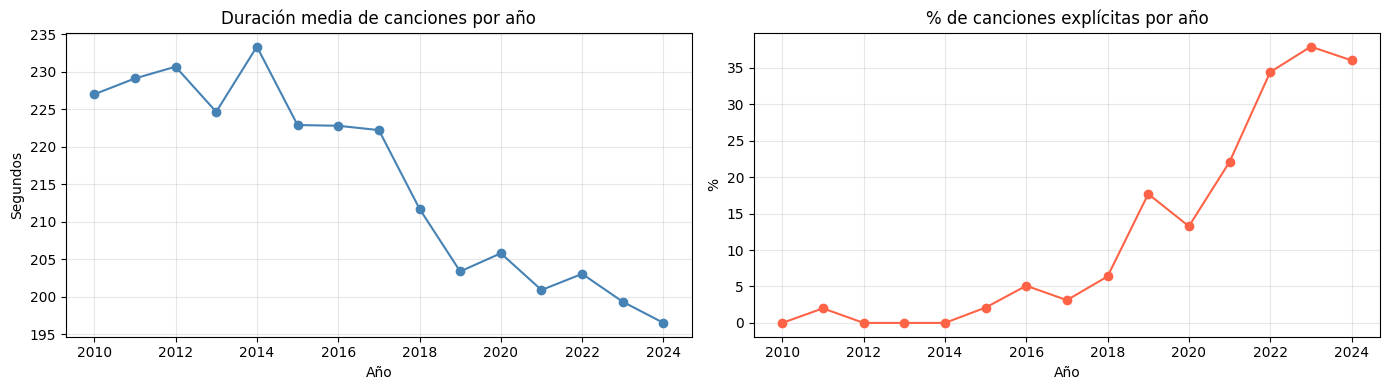

/tmp/ipykernel_19392/909467714.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


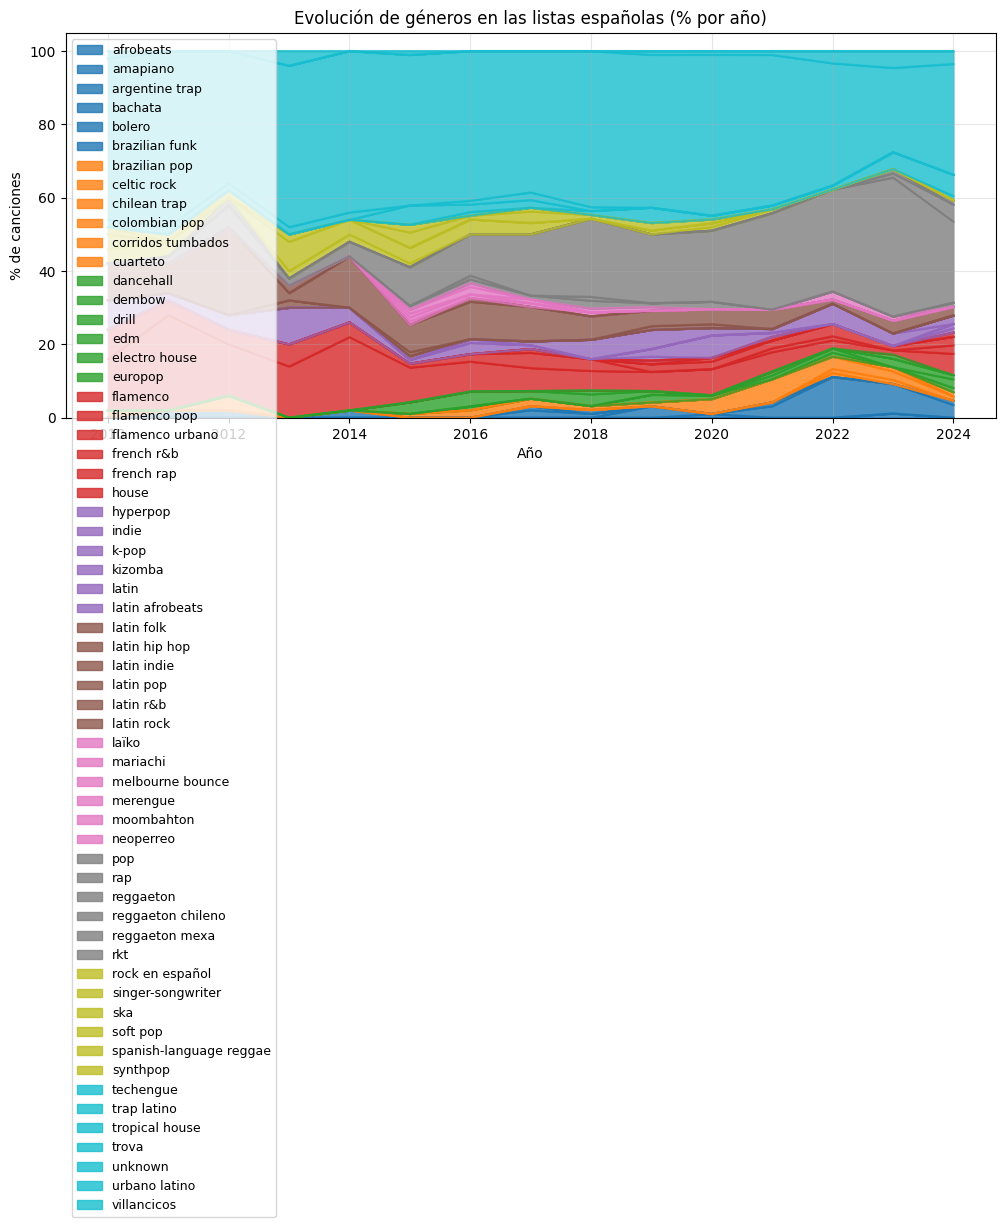

In [ ]:
# Distribución de géneros
print("Distribución de genre_group:")
print(df_spotify_clean["genre_group"].value_counts())
print("\nPorcentaje de canciones explícitas por año:")
print(df_spotify_clean.groupby("year")["explicit"].mean().round(3) * 100)

# Evolución de la duración media de las canciones año a año (antes de agregar)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_spotify_clean.groupby("year")["duration_sec"].mean().plot(ax=axes[0], marker="o", color="steelblue")
axes[0].set_title("Duración media de canciones por año")
axes[0].set_ylabel("Segundos")
axes[0].set_xlabel("Año")
axes[0].grid(alpha=0.3)

df_spotify_clean.groupby("year")["explicit"].mean().mul(100).plot(ax=axes[1], marker="o", color="tomato")
axes[1].set_title("% de canciones explícitas por año")
axes[1].set_ylabel("%")
axes[1].set_xlabel("Año")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Evolución de géneros a lo largo del tiempo
genre_year = df_spotify_clean.groupby(["year", "genre_group"]).size().unstack(fill_value=0)
genre_year_pct = genre_year.div(genre_year.sum(axis=1), axis=0) * 100

genre_year_pct.plot(kind="area", stacked=True, figsize=(12, 5), colormap="tab10", alpha=0.8)
plt.title("Evolución de géneros en las listas españolas (% por año)")
plt.ylabel("% de canciones")
plt.xlabel("Año")
plt.legend(loc="upper left", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## ANÁLISIS DESCRIPTIVO — Nivel de canción


In [ ]:
cols_desc_cancion = ["duration_sec", "popularity", "artist_popularity"]

desc = df_spotify_clean[cols_desc_cancion].describe().T
desc["cv"] = (desc["std"] / desc["mean"]).round(3)
desc = desc[["count", "mean", "std", "cv", "min", "25%", "50%", "75%", "max"]].round(2)
desc.columns = ["N", "Media", "Desv. tip.", "CV", "Min", "P25", "Mediana", "P75", "Max"]

display(
    desc.style
    .set_caption('Estadísticos descriptivos — nivel de canción')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold'), ('padding-bottom', '8px')]},
        {'selector': 'thead th', 'props': [('background-color', '#1a3a5c'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#f0f4f8')]},
        {'selector': 'tbody tr:hover', 'props': [('background-color', '#d6e4f0')]},
        {'selector': 'td, th', 'props': [('padding', '6px 12px'), ('text-align', 'center')]},
    ])
    .format({'N': '{:.0f}', 'Media': '{:.2f}', 'Desv. tip.': '{:.2f}', 'CV': '{:.2f}',
             'Min': '{:.2f}', 'P25': '{:.2f}', 'Mediana': '{:.2f}', 'P75': '{:.2f}', 'Max': '{:.2f}'})
)
print("Nota: el CV (std/media) permite comparar la dispersión relativa entre variables en distintas escalas.")

vc = df_spotify_clean["genre_group"].value_counts()
pct = (vc / vc.sum() * 100).round(1)
tabla_generos = pd.DataFrame({"N canciones": vc, "% total": pct}).head(10).reset_index()
tabla_generos.columns = ["Género", "N canciones", "% total"]
display(styled_table(tabla_generos, 'Distribución de genre_group (top 10)').format({'N canciones': '{:.0f}', '% total': '{:.1f}'}))


,N,Media,Desv. tip.,CV,Min,P25,Mediana,P75,Max
duration_sec,1185,213.31,40.92,0.19,105.84,187.44,209.92,233.07,519.29
popularity,1185,54.80,19.26,0.35,0.00,42.00,57.00,70.00,90.00
artist_popularity,1185,66.52,16.30,0.24,2.00,55.00,69.00,80.00,100.00


Nota: el CV (std/media) permite comparar la dispersión relativa entre variables en distintas escalas.


,Género,N canciones,% total
0,unknown,462,39.0
1,reggaeton,203,17.1
2,flamenco,97,8.2
3,latin pop,80,6.8
4,indie,29,2.4
5,flamenco pop,27,2.3
6,argentine trap,26,2.2
7,colombian pop,25,2.1
8,latin,22,1.9
9,singer-songwriter,21,1.8


Agregamos por año para poder analizar correctamente

In [ ]:
df_year = df_spotify_clean.groupby("year").agg(
    avg_duration         = ("duration_sec",      "mean"),
    avg_popularity       = ("popularity",         "mean"),
    std_popularity       = ("popularity",         "std"),
    avg_artist_popularity= ("artist_popularity",  "mean"),
    explicit_ratio       = ("explicit",            "mean"),
    n_songs              = ("track_name",          "count"),
    n_unique_artists     = ("artist_name",         "nunique"),
    avg_years_since_rel  = ("years_since_release", "mean"),
).reset_index()

genre_dominante = df_spotify_clean.groupby("year")["genre_group"].agg(
    lambda x: x.value_counts().idxmax()
).reset_index().rename(columns={"genre_group": "dominant_genre"})

genre_pct = df_spotify_clean.groupby(["year", "genre_group"]).size().unstack(fill_value=0)
genre_pct = genre_pct.div(genre_pct.sum(axis=1), axis=0).round(4)
genre_pct.columns = [f"pct_{g}" for g in genre_pct.columns]
genre_pct = genre_pct.reset_index()

df_year = df_year.merge(genre_dominante, on="year", how="left")
df_year = df_year.merge(genre_pct, on="year", how="left")

print("Dataset anual shape:", df_year.shape)


cols_preview = ["year", "avg_duration", "avg_popularity", "std_popularity",
                "avg_artist_popularity", "explicit_ratio", "n_songs",
                "n_unique_artists", "avg_years_since_rel", "dominant_genre"]
display(styled_table(df_year[cols_preview], 'Dataset anual — variables principales').format({
    'year': '{:.0f}', 'n_songs': '{:.0f}', 'n_unique_artists': '{:.0f}',
    'avg_duration': '{:.2f}', 'avg_popularity': '{:.2f}', 'std_popularity': '{:.2f}',
    'avg_artist_popularity': '{:.2f}', 'explicit_ratio': '{:.2f}', 'avg_years_since_rel': '{:.2f}'
}))


Dataset anual shape: (15, 71)


,year,avg_duration,avg_popularity,std_popularity,avg_artist_popularity,explicit_ratio,n_songs,n_unique_artists,avg_years_since_rel,dominant_genre
0,2010,227.00,41.52,16.42,54.24,0.00,50,42,0.56,unknown
1,2011,229.12,37.20,17.49,51.42,0.02,50,41,-0.14,unknown
2,2012,230.69,43.46,17.88,57.26,0.00,50,38,-0.16,unknown
3,2013,224.66,40.28,14.26,54.00,0.00,50,40,-0.10,unknown
4,2014,233.36,43.24,16.21,57.22,0.00,50,42,-0.02,unknown
5,2015,222.90,54.22,20.68,64.94,0.02,95,85,-0.24,unknown
6,2016,222.80,56.64,21.25,66.00,0.05,98,85,0.13,unknown
7,2017,222.22,56.07,19.46,67.46,0.03,96,85,-0.02,unknown
8,2018,211.72,54.84,17.48,68.02,0.06,94,76,0.04,unknown
9,2019,203.35,54.27,16.29,68.23,0.18,96,79,0.12,unknown


Limpieza de los datos del PIB

In [ ]:
df_spotify_pib = df_pib[df_pib["Country Name"].astype(str).str.strip() == "España"].copy()
df_spotify_pib = df_spotify_pib.drop(columns=["Country Name", "Country Code", "Indicator Name", "Indicator Code"])
df_spotify_pib = df_spotify_pib.melt(var_name="year", value_name="pib_per_capita")
df_spotify_pib["year"] = pd.to_numeric(df_spotify_pib["year"], errors="coerce")
df_spotify_pib["pib_per_capita"] = pd.to_numeric(df_spotify_pib["pib_per_capita"], errors="coerce")
df_spotify_pib = df_spotify_pib[(df_spotify_pib["year"] >= 2010) & (df_spotify_pib["year"] <= 2024)]

nulos_pib = int(df_spotify_pib["pib_per_capita"].isnull().sum())
resumen_pib = pd.DataFrame({
    "Métrica": ["Total de filas (2010–2024)", "Nulos en 'year'", "Nulos en 'pib_per_capita'"],
    "Valor":   [len(df_spotify_pib), int(df_spotify_pib["year"].isnull().sum()), f"{nulos_pib} ({round(nulos_pib/len(df_spotify_pib)*100,1)}%)"]
})
display(styled_table(resumen_pib, 'Diagnóstico de nulos — PIB per cápita'))

if nulos_pib > 0:
    filas_nulas_pib = df_spotify_pib[df_spotify_pib["pib_per_capita"].isnull()][["year", "pib_per_capita"]].copy()
    filas_nulas_pib["year"] = filas_nulas_pib["year"].astype(int)
    filas_nulas_pib.columns = ["Año", "PIB per cápita"]
    display(styled_table(filas_nulas_pib.reset_index(drop=True), f'Años con pib_per_capita nulo — {nulos_pib} casos').format({'Año': '{:.0f}'}))
    print("→ Decisión: se eliminan estas filas.")

df_spotify_pib = df_spotify_pib.dropna().reset_index(drop=True)
display(styled_table(df_spotify_pib.head(), 'Vista previa — PIB per cápita').format({'year': '{:.0f}', 'pib_per_capita': '{:.2f}'}))
print("Años disponibles:", sorted(df_spotify_pib["year"].unique().tolist()))


,Métrica,Valor
0,Total de filas (2010–2024),15
1,Nulos en 'year',0
2,Nulos en 'pib_per_capita',0 (0.0%)


,year,pib_per_capita
0,2010,30658.74
1,2011,31824.62
2,2012,28456.44
3,2013,29228.85
4,2014,29707.77


Años disponibles: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


Limpieza de los datos de acceso a internet

In [ ]:
df_spotify_internet = df_internet[df_internet["Country Name"].astype(str).str.strip() == "España"].copy()
df_spotify_internet = df_spotify_internet.drop(columns=["Country Name", "Country Code", "Indicator Name", "Indicator Code"])
df_spotify_internet = df_spotify_internet.melt(var_name="year", value_name="internet_access")
df_spotify_internet["year"] = pd.to_numeric(df_spotify_internet["year"], errors="coerce")
df_spotify_internet["internet_access"] = pd.to_numeric(df_spotify_internet["internet_access"], errors="coerce")
df_spotify_internet = df_spotify_internet[(df_spotify_internet["year"] >= 2010) & (df_spotify_internet["year"] <= 2024)]

nulos_int = int(df_spotify_internet["internet_access"].isnull().sum())
resumen_int = pd.DataFrame({
    "Métrica": ["Total de filas (2010–2024)", "Nulos en 'year'", "Nulos en 'internet_access'"],
    "Valor":   [len(df_spotify_internet), int(df_spotify_internet["year"].isnull().sum()), f"{nulos_int} ({round(nulos_int/len(df_spotify_internet)*100,1)}%)"]
})
display(styled_table(resumen_int, 'Diagnóstico de nulos — Acceso a internet'))

if nulos_int > 0:
    filas_nulas_int = df_spotify_internet[df_spotify_internet["internet_access"].isnull()][["year", "internet_access"]].copy()
    filas_nulas_int["year"] = filas_nulas_int["year"].astype(int)
    filas_nulas_int.columns = ["Año", "Acceso a internet (%)"]
    display(styled_table(filas_nulas_int.reset_index(drop=True), f'Años con internet_access nulo — {nulos_int} casos').format({'Año': '{:.0f}'}))

df_spotify_internet = df_spotify_internet.dropna().reset_index(drop=True)
display(styled_table(df_spotify_internet.head(), 'Vista previa — Acceso a internet').format({'year': '{:.0f}', 'internet_access': '{:.2f}'}))
print("Años disponibles:", sorted(df_spotify_internet["year"].unique().tolist()))


,Métrica,Valor
0,Total de filas (2010–2024),15
1,Nulos en 'year',0
2,Nulos en 'internet_access',0 (0.0%)


,year,internet_access
0,2010,65.80
1,2011,67.09
2,2012,69.81
3,2013,71.64
4,2014,76.19


Años disponibles: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


Unimos los tres datsets

In [ ]:
# unimos los dos datasets

df_spotify_year = df_year.copy()


df_spotify_pib["year"] = pd.to_numeric(df_spotify_pib["year"], errors="coerce").astype(int)

# merge PIB data
df_spotify_year = df_spotify_year.drop(columns=["pib_per_capita"], errors="ignore")
df_spotify_year = df_spotify_year.merge(df_spotify_pib, on="year", how="left")

df_spotify_internet["year"] = pd.to_numeric(df_spotify_internet["year"], errors="coerce").astype(int)

# merge internet access data
df_spotify_year = df_spotify_year.drop(columns=["internet_access"], errors="ignore")
df_spotify_year = df_spotify_year.merge(df_spotify_internet, on="year", how="left")

print(df_spotify_year.head())
print(df_spotify_year.isnull().sum())

   year  avg_duration  avg_popularity  std_popularity  avg_artist_popularity  \
0  2010     226.99924           41.52       16.423279                  54.24   
1  2011     229.11840           37.20       17.487021                  51.42   
2  2012     230.68654           43.46       17.881937                  57.26   
3  2013     224.66192           40.28       14.255740                  54.00   
4  2014     233.36278           43.24       16.213575                  57.22   

   explicit_ratio  n_songs  n_unique_artists  avg_years_since_rel  \
0            0.00       50                42                 0.56   
1            0.02       50                41                -0.14   
2            0.00       50                38                -0.16   
3            0.00       50                40                 -0.1   
4            0.00       50                42                -0.02   

  dominant_genre  pct_afrobeats  pct_amapiano  pct_argentine trap  \
0        unknown            0.0    

Comprobaciones finales

In [ ]:
# validamos el dataset final
print(df_spotify_year.info())
print(df_spotify_year.describe())
print(df_spotify_year.isnull().sum())

# comprobamos los años
print("Año mínimo:", df_spotify_year["year"].min())
print("Año máximo:", df_spotify_year["year"].max())
print("Número de filas:", len(df_spotify_year))
print("Años:", sorted(df_spotify_year["year"].tolist()))

# ordenamos el dataset final por año
df_spotify_year = df_spotify_year.sort_values("year").reset_index(drop=True)
df_spotify_year.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 73 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   year                         15 non-null     int64  
 1   avg_duration                 15 non-null     float64
 2   avg_popularity               15 non-null     float64
 3   std_popularity               15 non-null     float64
 4   avg_artist_popularity        15 non-null     float64
 5   explicit_ratio               15 non-null     float64
 6   n_songs                      15 non-null     int64  
 7   n_unique_artists             15 non-null     int64  
 8   avg_years_since_rel          15 non-null     Float64
 9   dominant_genre               15 non-null     object 
 10  pct_afrobeats                15 non-null     float64
 11  pct_amapiano                 15 non-null     float64
 12  pct_argentine trap           15 non-null     float64
 13  pct_bachata           

,year,avg_duration,avg_popularity,std_popularity,avg_artist_popularity,explicit_ratio,n_songs,n_unique_artists,avg_years_since_rel,dominant_genre,pct_afrobeats,pct_amapiano,pct_argentine trap,pct_bachata,pct_bolero,pct_brazilian funk,pct_brazilian pop,pct_celtic rock,pct_chilean trap,pct_colombian pop,pct_corridos tumbados,pct_cuarteto,pct_dancehall,pct_dembow,pct_drill,pct_edm,pct_electro house,pct_europop,pct_flamenco,pct_flamenco pop,pct_flamenco urbano,pct_french r&b,pct_french rap,pct_house,pct_hyperpop,pct_indie,pct_k-pop,pct_kizomba,pct_latin,pct_latin afrobeats,pct_latin folk,pct_latin hip hop,pct_latin indie,pct_latin pop,pct_latin r&b,pct_latin rock,pct_laïko,pct_mariachi,pct_melbourne bounce,pct_merengue,pct_moombahton,pct_neoperreo,pct_pop,pct_rap,pct_reggaeton,pct_reggaeton chileno,pct_reggaeton mexa,pct_rkt,pct_rock en español,pct_singer-songwriter,pct_ska,pct_soft pop,pct_spanish-language reggae,pct_synthpop,pct_techengue,pct_trap latino,pct_tropical house,pct_trova,pct_unknown,pct_urbano latino,pct_villancicos,pib_per_capita,internet_access
0,2010,226.99924,41.52,16.423279,54.24,0.00,50,42,0.56,unknown,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.02,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.14,0.08,0.0,0.0,0.0,0.0,0.0,0.08,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.10,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.04,0.04,0.00,0.0,0.02,0.00,0.0,0.0,0.0,0.02,0.44,0.0,0.02,30658.742228,65.8000
1,2011,229.11840,37.20,17.487021,51.42,0.02,50,41,-0.14,unknown,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.26,0.04,0.0,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.08,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.00,0.04,0.00,0.00,0.0,0.00,0.02,0.0,0.0,0.0,0.02,0.48,0.0,0.00,31824.621913,67.0900
2,2012,230.68654,43.46,17.881937,57.26,0.00,50,38,-0.16,unknown,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.00,0.0,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.14,0.04,0.0,0.0,0.0,0.0,0.0,0.04,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.24,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.06,0.0,0.0,0.02,0.00,0.00,0.00,0.0,0.02,0.00,0.0,0.0,0.0,0.02,0.36,0.0,0.00,28456.443815,69.8100
3,2013,224.66192,40.28,14.255740,54.00,0.00,50,40,-0.1,unknown,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.14,0.06,0.0,0.0,0.0,0.0,0.0,0.10,0.0,0.0,0.0,0.0,0.0,0.02,0.0,0.02,0.0,0.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.00,0.02,0.08,0.02,0.0,0.00,0.00,0.0,0.0,0.0,0.02,0.44,0.0,0.04,29228.846560,71.6350
4,2014,233.36278,43.24,16.213575,57.22,0.00,50,42,-0.02,unknown,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.20,0.04,0.0,0.0,0.0,0.0,0.0,0.04,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.14,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.04,0.0,0.0,0.00,0.02,0.04,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.02,0.44,0.0,0.00,29707.765509,76.1867


Analisis exploratorio del dataset anual

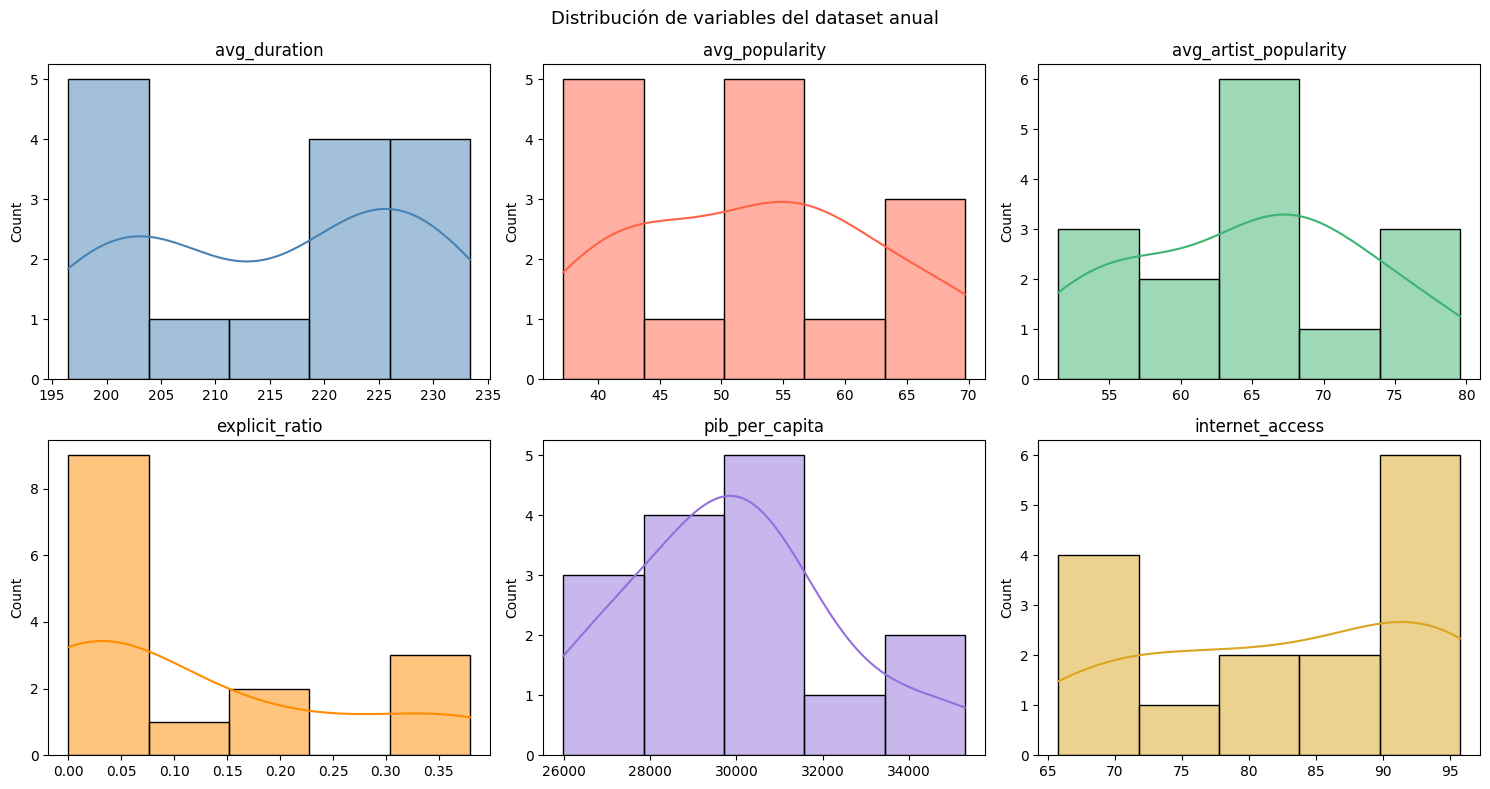

In [ ]:
colores = ['steelblue', 'tomato', 'mediumseagreen', 'darkorange', 'mediumpurple', 'goldenrod']
cols_plot = ["avg_duration", "avg_popularity", "avg_artist_popularity", "explicit_ratio", "pib_per_capita", "internet_access"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col, color in zip(axes, cols_plot, colores):
    sns.histplot(df_spotify_year[col], kde=True, ax=ax, color=color)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Distribución de variables del dataset anual", fontsize=13)
plt.tight_layout()
plt.show()

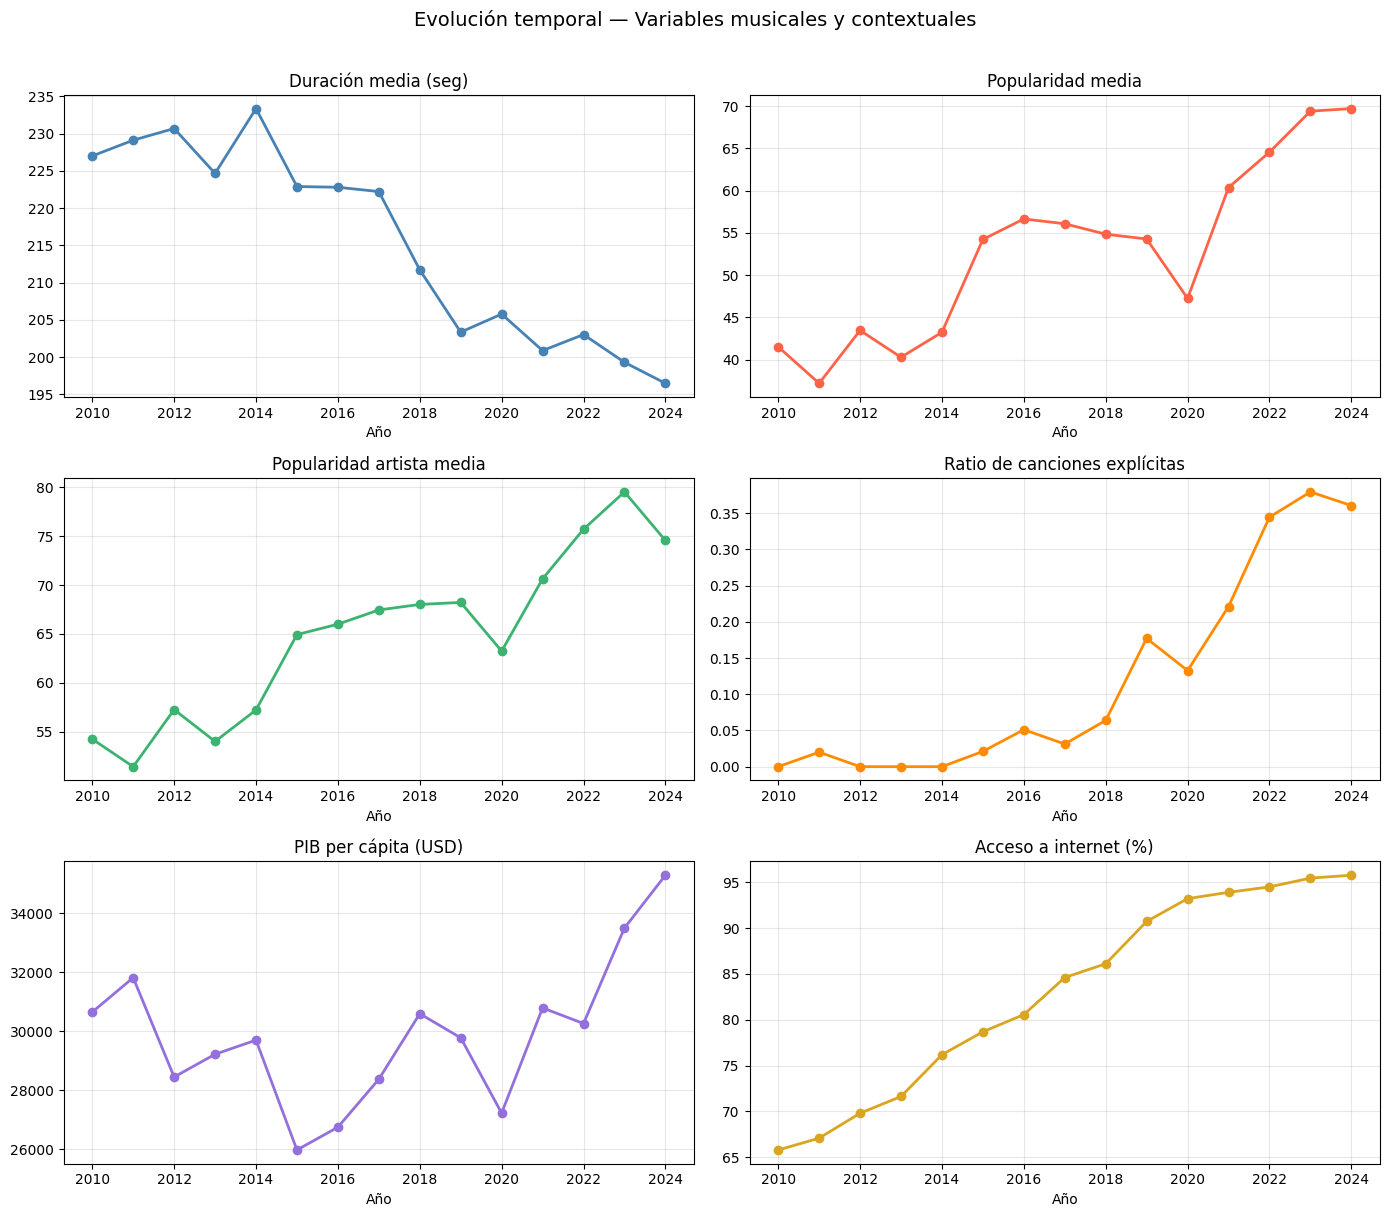

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

variables_evo = [
    ("avg_duration",          "Duración media (seg)"),
    ("avg_popularity",        "Popularidad media"),
    ("avg_artist_popularity", "Popularidad artista media"),
    ("explicit_ratio",        "Ratio de canciones explícitas"),
    ("pib_per_capita",        "PIB per cápita (USD)"),
    ("internet_access",       "Acceso a internet (%)"),
]

colores = ['steelblue', 'tomato', 'mediumseagreen', 'darkorange', 'mediumpurple', 'goldenrod']

for ax, (col, label), color in zip(axes, variables_evo, colores):
    ax.plot(df_spotify_year["year"], df_spotify_year[col], marker="o", linewidth=2, color=color)
    ax.set_title(label)
    ax.set_xlabel("Año")
    ax.grid(True, alpha=0.3)



plt.suptitle("Evolución temporal — Variables musicales y contextuales", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

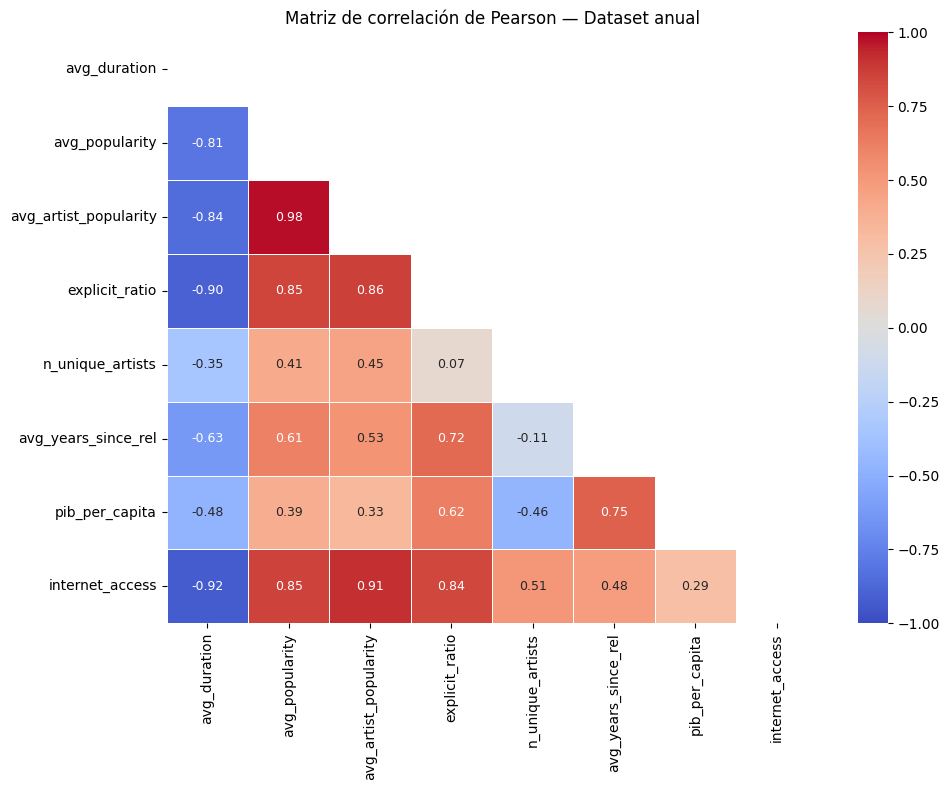


Correlaciones con avg_popularity (ordenadas):
avg_artist_popularity    0.979
internet_access          0.854
explicit_ratio           0.850
avg_duration            -0.806
avg_years_since_rel      0.611
n_unique_artists         0.409
pib_per_capita           0.391
Name: avg_popularity, dtype: float64


In [ ]:
cols_corr = ["avg_duration", "avg_popularity", "avg_artist_popularity",
             "explicit_ratio", "n_unique_artists", "avg_years_since_rel",
             "pib_per_capita", "internet_access"]

corr_matrix = df_spotify_year[cols_corr].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={"size": 9})
plt.title("Matriz de correlación de Pearson — Dataset anual", fontsize=12)
plt.tight_layout()
plt.show()

# Correlaciones más fuertes con popularidad
print("\nCorrelaciones con avg_popularity (ordenadas):")
print(corr_matrix["avg_popularity"].drop("avg_popularity").sort_values(key=abs, ascending=False).round(3))

In [ ]:
cols_adf = ["avg_duration", "avg_popularity", "avg_artist_popularity",
            "explicit_ratio", "pib_per_capita", "internet_access"]


resultados_adf = []
for col in cols_adf:
    serie = df_spotify_year[col].dropna()
    try:
        result    = adfuller(serie, autolag="AIC")
        adf_stat  = result[0]
        p_val     = result[1]
        estacion  = "Sí" if p_val < 0.05 else "No"
        resultados_adf.append({"Variable": col, "ADF": round(adf_stat, 4),
                                "p-valor": round(p_val, 4), "¿Estacionaria?": estacion})
    except Exception as e:
        resultados_adf.append({"Variable": col, "ADF": "Error", "p-valor": "-", "¿Estacionaria?": "-"})

df_adf = pd.DataFrame(resultados_adf)
display(styled_table(df_adf, 'Test de Dickey-Fuller Aumentado (ADF) — Series temporales anuales')
        .format({'ADF': '{:.4f}', 'p-valor': '{:.4f}'}))

print("Nota: con solo 15 observaciones anuales el test ADF tiene poco poder estadístico.")
print("Para ARIMA se aplicará diferenciación de primer orden a las series no estacionarias.")



,Variable,ADF,p-valor,¿Estacionaria?
0,avg_duration,-0.2942,0.9263,No
1,avg_popularity,-0.4685,0.8980,No
2,avg_artist_popularity,-0.9949,0.7551,No
3,explicit_ratio,-0.1034,0.9491,No
4,pib_per_capita,-1.1230,0.7058,No
5,internet_access,-1.5738,0.4968,No


Nota: con solo 15 observaciones anuales el test ADF tiene poco poder estadístico.
Para ARIMA se aplicará diferenciación de primer orden a las series no estacionarias.


Exportación del dataset final

In [ ]:
# Dataset anual agregado (para modelos ARIMA, Random Forest, correlaciones)
df_spotify_year.to_csv("dataset_anual_spotify_macro.csv", index=False)

# Dataset a nivel de canción limpio (para PCA, K-Means, regresión)
df_spotify_clean.to_csv("dataset_canciones_limpio.csv", index=False)



print("Archivos exportados:")
print(f"  → dataset_anual_spotify_macro.csv   ({df_spotify_year.shape[0]} filas, {df_spotify_year.shape[1]} columnas)")
print(f"  → dataset_canciones_limpio.csv      ({df_spotify_clean.shape[0]} filas, {df_spotify_clean.shape[1]} columnas)")

Archivos exportados:
  → dataset_anual_spotify_macro.csv   (15 filas, 73 columnas)
  → dataset_canciones_limpio.csv      (1185 filas, 16 columnas)


---
## ANÁLISIS DESCRIPTIVO — Dataset anual agregado
Estadísticos descriptivos del dataset de 15 observaciones anuales (2010–2024) resultante de la agregación y el merge con PIB e internet.

In [ ]:
cols_desc_anual = [
    "avg_duration", "avg_popularity", "avg_artist_popularity",
    "explicit_ratio", "n_unique_artists", "avg_years_since_rel",
    "pib_per_capita", "internet_access"
]

desc_anual = df_spotify_year[cols_desc_anual].describe().T
desc_anual["cv"] = (desc_anual["std"] / desc_anual["mean"]).round(3)
desc_anual = desc_anual[["count", "mean", "std", "cv", "min", "50%", "max"]].round(2)
desc_anual.columns = ["N", "Media", "Desv. tip.", "CV", "Min", "Mediana", "Max"]

display(
    desc_anual.style
    .set_caption('Estadísticos descriptivos — Dataset anual (2010–2024)')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold'), ('padding-bottom', '8px')]},
        {'selector': 'thead th', 'props': [('background-color', '#1a3a5c'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#f0f4f8')]},
        {'selector': 'tbody tr:hover', 'props': [('background-color', '#d6e4f0')]},
        {'selector': 'td, th', 'props': [('padding', '6px 12px'), ('text-align', 'center')]},
    ])
    .format({'N': '{:.0f}', 'Media': '{:.2f}', 'Desv. tip.': '{:.2f}', 'CV': '{:.2f}',
             'Min': '{:.2f}', 'Mediana': '{:.2f}', 'Max': '{:.2f}'})
)
print("Nota: con solo 15 observaciones anuales los estadísticos tienen carácter orientativo.")


,N,Media,Desv. tip.,CV,Min,Mediana,Max
avg_duration,15,215.55,12.97,0.06,196.48,222.22,233.36
avg_popularity,15,52.87,10.44,0.20,37.20,54.27,69.70
avg_artist_popularity,15,64.83,8.54,0.13,51.42,66.00,79.54
explicit_ratio,15,0.12,0.14,1.18,0.00,0.05,0.38
n_unique_artists,15,62.00,18.87,0.30,38.00,58.00,85.00
avg_years_since_rel,15,0.17,0.37,2.15,-0.24,0.12,1.17
pib_per_capita,15,29899.63,2465.55,0.08,25982.44,29786.52,35297.01
internet_access,15,82.93,10.91,0.13,65.80,84.60,95.76


Nota: con solo 15 observaciones anuales los estadísticos tienen carácter orientativo.
